# サポートベクターマシン (SVM)

In [5]:
!pip install japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 80.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3960c890bc403dea3e7f30db5dd27d3e7d057d25fa5b02895c2afe40d01265f3
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


## 基本的な訓練と評価

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ───────────────────────────
# データの準備
# ───────────────────────────
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# SVM では特徴量のスケーリングが必須
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ───────────────────────────
# モデルの構築と学習
# ───────────────────────────
svm = SVC(
    kernel='rbf',           # カーネル関数
    C=1.0,                  # 正則化パラメータ
    gamma='scale',          # RBF カーネルのパラメータ
    random_state=42
)
svm.fit(X_train_sc, y_train)

# ───────────────────────────
# 予測と評価
# ───────────────────────────
y_pred = svm.predict(X_test_sc)

print(f"正解率 (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(
    y_test, y_pred, target_names=iris.target_names
))


正解率 (Accuracy): 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



## サポートベクターの確認

In [2]:
print("=== サポートベクターの情報 ===\n")
print(f"サポートベクターの総数: {svm.n_support_.sum()} / {len(X_train)} "
      f"({svm.n_support_.sum()/len(X_train)*100:.1f}%)")
print(f"クラス別サポートベクター数:")
for name, count in zip(iris.target_names, svm.n_support_):
    print(f"  {name:12s}: {count}")

# サポートベクターのインデックスと詳細
print(f"\nサポートベクターのインデックス（先頭 10 個）:")
print(f"  {svm.support_[:10]}")

# 双対係数（ラグランジュ乗数 × クラスラベル）
print(f"\n双対係数の形状: {svm.dual_coef_.shape}")
print(f"双対係数の範囲: [{svm.dual_coef_.min():.4f}, {svm.dual_coef_.max():.4f}]")


=== サポートベクターの情報 ===

サポートベクターの総数: 40 / 105 (38.1%)
クラス別サポートベクター数:
  setosa      : 6
  versicolor  : 18
  virginica   : 16

サポートベクターのインデックス（先頭 10 個）:
  [12 20 25 30 51 80  0  1 13 19]

双対係数の形状: (2, 40)
双対係数の範囲: [-1.0000, 1.0000]


## カーネルの比較

In [3]:
from sklearn.model_selection import cross_val_score

kernels = {
    '線形 (linear)':     {'kernel': 'linear', 'C': 1.0},
    '多項式 d=2 (poly)': {'kernel': 'poly', 'degree': 2, 'C': 1.0},
    '多項式 d=3 (poly)': {'kernel': 'poly', 'degree': 3, 'C': 1.0},
    'RBF (rbf)':         {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'},
    'シグモイド':         {'kernel': 'sigmoid', 'C': 1.0, 'gamma': 'scale'},
}

print(f"{'カーネル':<22s}  |  交差検証スコア (平均 ± 標準偏差)")
print("-" * 58)

for name, params in kernels.items():
    svm_k = SVC(**params, random_state=42)
    scores = cross_val_score(svm_k, X_train_sc, y_train, cv=5)
    print(f"{name:<22s}  |  {scores.mean():.4f} ± {scores.std():.4f}")


カーネル                    |  交差検証スコア (平均 ± 標準偏差)
----------------------------------------------------------
線形 (linear)             |  0.9714 ± 0.0233
多項式 d=2 (poly)          |  0.8762 ± 0.0646
多項式 d=3 (poly)          |  0.8952 ± 0.0190
RBF (rbf)               |  0.9714 ± 0.0233
シグモイド                   |  0.9238 ± 0.0233


## 決定境界の可視化

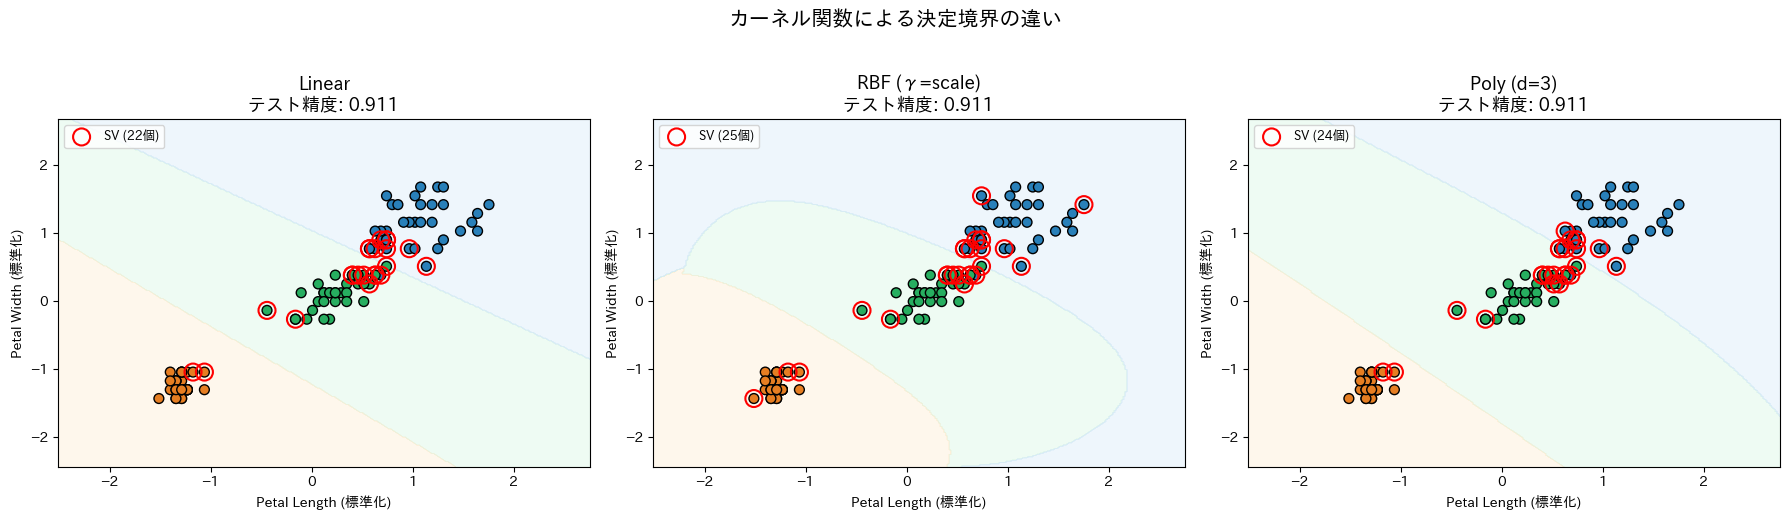

In [6]:
import matplotlib.pyplot as plt
import japanize_matplotlib
from matplotlib.colors import ListedColormap

X_vis = iris.data[:, 2:4]
y_vis = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42, stratify=y_vis
)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

x_min, x_max = X_tr_sc[:, 0].min() - 1, X_tr_sc[:, 0].max() + 1
y_min, y_max = X_tr_sc[:, 1].min() - 1, X_tr_sc[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

cmap_bg = ListedColormap(['#FDEBD0', '#D5F5E3', '#D6EAF8'])
cmap_pt = ListedColormap(['#E67E22', '#27AE60', '#2980B9'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

kernel_configs = [
    ('Linear', {'kernel': 'linear', 'C': 1.0}),
    ('RBF (γ=scale)', {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}),
    ('Poly (d=3)', {'kernel': 'poly', 'degree': 3, 'C': 1.0}),
]

for ax, (name, params) in zip(axes, kernel_configs):
    model = SVC(**params, random_state=42)
    model.fit(X_tr_sc, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = model.score(X_te_sc, y_te)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr_sc[:, 0], X_tr_sc[:, 1], c=y_tr, cmap=cmap_pt,
               edgecolors='k', s=50)
    # サポートベクターを強調表示
    ax.scatter(X_tr_sc[model.support_, 0], X_tr_sc[model.support_, 1],
               s=150, facecolors='none', edgecolors='red', linewidths=1.5,
               label=f'SV ({len(model.support_)}個)')
    ax.set_title(f'{name}\nテスト精度: {acc:.3f}', fontsize=13)
    ax.set_xlabel('Petal Length (標準化)')
    ax.set_ylabel('Petal Width (標準化)')
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle('カーネル関数による決定境界の違い', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('svm_kernel_comparison.png', dpi=150)
plt.show()


## C と gamma のグリッドサーチ

=== グリッドサーチ結果 ===

最適パラメータ: {'C': 1, 'gamma': 0.1}
最良 CV スコア: 0.9810
テストスコア:   0.9111


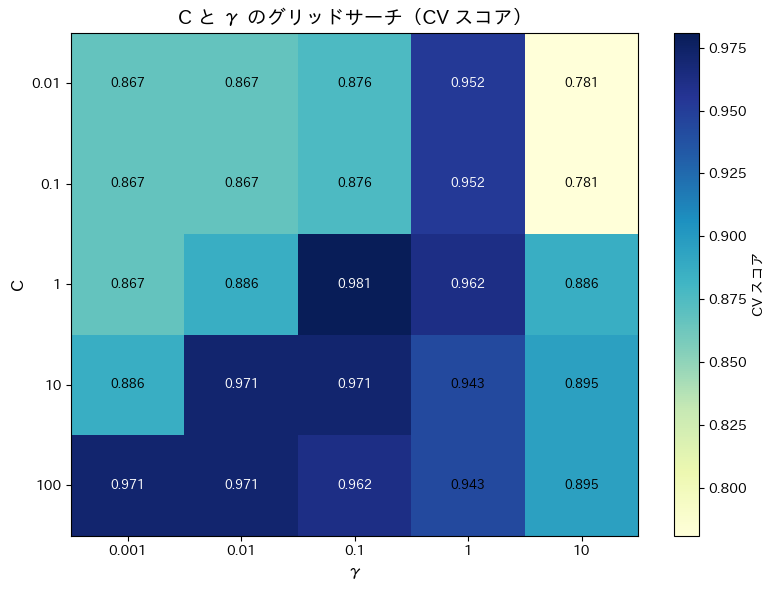

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 'scale'],
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train_sc, y_train)

print("=== グリッドサーチ結果 ===\n")
print(f"最適パラメータ: {grid_search.best_params_}")
print(f"最良 CV スコア: {grid_search.best_score_:.4f}")
print(f"テストスコア:   {grid_search.score(X_test_sc, y_test):.4f}")

# 結果のヒートマップ表示
results = grid_search.cv_results_
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

# gamma='scale' を除いた数値パラメータのみでヒートマップ作成
scores_matrix = np.zeros((len(C_values), len(gamma_values)))
for i, C in enumerate(C_values):
    for j, g in enumerate(gamma_values):
        mask = (results['param_C'].data == C) & (results['param_gamma'].data == g)
        if mask.any():
            scores_matrix[i, j] = results['mean_test_score'][mask][0]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(scores_matrix, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(gamma_values)))
ax.set_xticklabels(gamma_values)
ax.set_yticks(range(len(C_values)))
ax.set_yticklabels(C_values)
ax.set_xlabel('γ', fontsize=12)
ax.set_ylabel('C', fontsize=12)
ax.set_title('C と γ のグリッドサーチ（CV スコア）', fontsize=14)

for i in range(len(C_values)):
    for j in range(len(gamma_values)):
        ax.text(j, i, f'{scores_matrix[i,j]:.3f}',
                ha='center', va='center', fontsize=9,
                color='white' if scores_matrix[i,j] > 0.95 else 'black')

plt.colorbar(im, label='CV スコア')
plt.tight_layout()
plt.savefig('svm_grid_search.png', dpi=150)
plt.show()


## C の影響の可視化

- C が小さい：SV 数が多い（多くの点がマージン内に許容）→ マージンが広い
- C が大きい：SV 数が少ない（誤分類を厳しく罰する）→ マージンが狭い


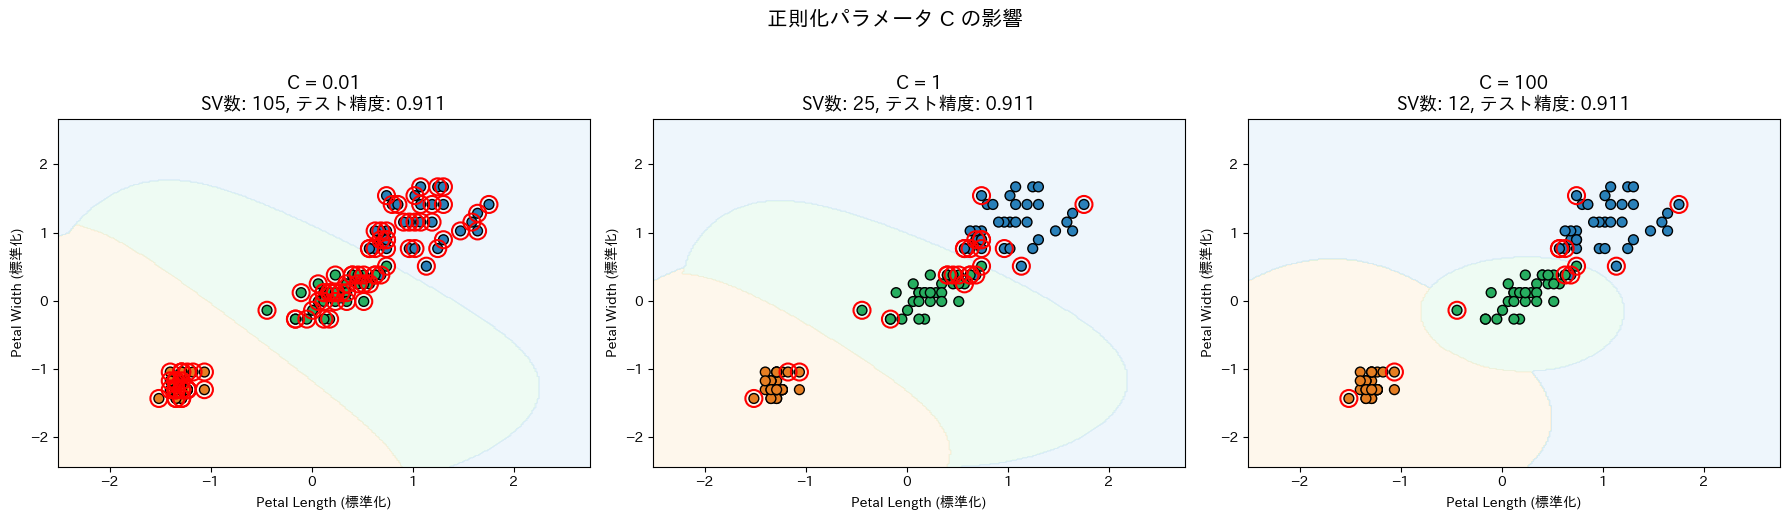

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, C_val in zip(axes, [0.01, 1, 100]):
    model = SVC(kernel='rbf', C=C_val, gamma='scale', random_state=42)
    model.fit(X_tr_sc, y_tr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc = model.score(X_te_sc, y_te)
    n_sv = len(model.support_)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.scatter(X_tr_sc[:, 0], X_tr_sc[:, 1], c=y_tr, cmap=cmap_pt,
               edgecolors='k', s=50)
    ax.scatter(X_tr_sc[model.support_, 0], X_tr_sc[model.support_, 1],
               s=150, facecolors='none', edgecolors='red', linewidths=1.5)
    ax.set_title(f'C = {C_val}\nSV数: {n_sv}, テスト精度: {acc:.3f}', fontsize=13)
    ax.set_xlabel('Petal Length (標準化)')
    ax.set_ylabel('Petal Width (標準化)')

plt.suptitle('正則化パラメータ C の影響', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig('svm_C_comparison.png', dpi=150)
plt.show()


## LinearSVC ─ 大規模データ向けの線形 SVM

- LinearSVC は liblinear を使用し，SVC(kernel='linear') より大幅に高速
- 大規模データでの線形分類には LinearSVC を推奨


In [9]:
import time
from sklearn.svm import LinearSVC
from sklearn.datasets import make_classification

# 大規模データの生成
X_large, y_large = make_classification(
    n_samples=50000, n_features=50, n_informative=20,
    n_classes=2, random_state=42
)
X_lg_tr, X_lg_te, y_lg_tr, y_lg_te = train_test_split(
    X_large, y_large, test_size=0.3, random_state=42
)
sc_lg = StandardScaler()
X_lg_tr_sc = sc_lg.fit_transform(X_lg_tr)
X_lg_te_sc = sc_lg.transform(X_lg_te)

models = {
    'SVC (linear kernel)': SVC(kernel='linear', C=1.0),
    'LinearSVC':           LinearSVC(C=1.0, max_iter=5000, random_state=42),
}

print(f"データ: 訓練={X_lg_tr.shape[0]:,}, 特徴量={X_lg_tr.shape[1]}\n")
print(f"{'モデル':<24s}  {'学習時間':>10s}  {'正解率':>8s}")
print("-" * 48)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_lg_tr_sc, y_lg_tr)
    t_fit = time.time() - t0
    acc = model.score(X_lg_te_sc, y_lg_te)
    print(f"{name:<24s}  {t_fit:>9.3f}s  {acc:>7.4f}")


データ: 訓練=35,000, 特徴量=50

モデル                             学習時間       正解率
------------------------------------------------
SVC (linear kernel)         302.091s   0.8001
LinearSVC                     0.236s   0.7989


## スケーリングの重要性の実証

In [10]:
# スケーリングの有無による性能比較
svm_no_scale = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_no_scale.fit(X_train, y_train)   # スケーリングなし
acc_no_scale = svm_no_scale.score(X_test, y_test)

svm_with_scale = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_with_scale.fit(X_train_sc, y_train)   # スケーリングあり
acc_with_scale = svm_with_scale.score(X_test_sc, y_test)

print("=== スケーリングの影響 ===\n")
print(f"スケーリングなし: {acc_no_scale:.4f}")
print(f"スケーリングあり: {acc_with_scale:.4f}")
print()
print("特徴量ごとの範囲（スケーリング前）:")
for i, name in enumerate(iris.feature_names):
    print(f"  {name:20s}: [{X_train[:, i].min():.1f}, {X_train[:, i].max():.1f}]")


=== スケーリングの影響 ===

スケーリングなし: 0.9556
スケーリングあり: 0.9333

特徴量ごとの範囲（スケーリング前）:
  sepal length (cm)   : [4.3, 7.9]
  sepal width (cm)    : [2.0, 4.4]
  petal length (cm)   : [1.1, 6.9]
  petal width (cm)    : [0.1, 2.5]
